Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


Tracking:   0%|          | 0/100 [00:00<?, ?it/s]

beta_rel: 0.99999
beta_rel: 0.99999


(1e-16, 10.0)

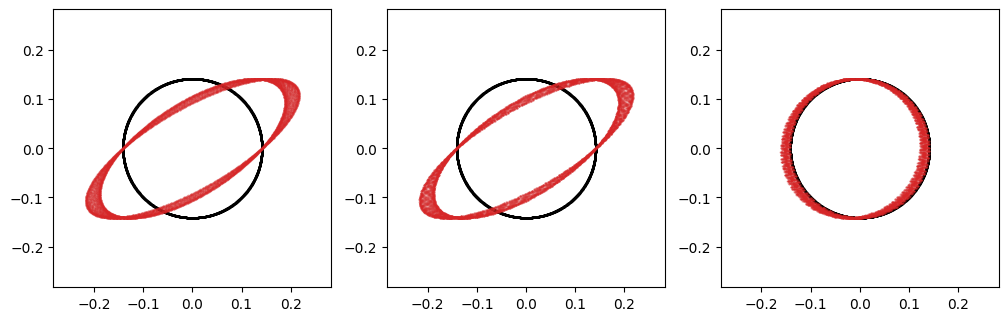

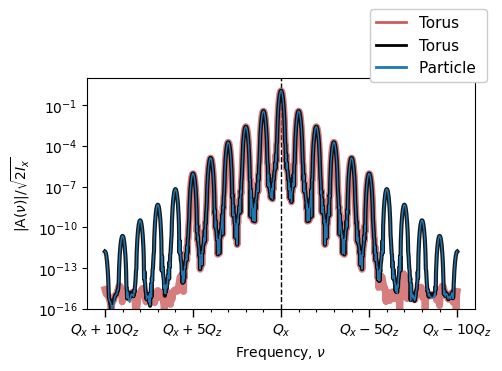

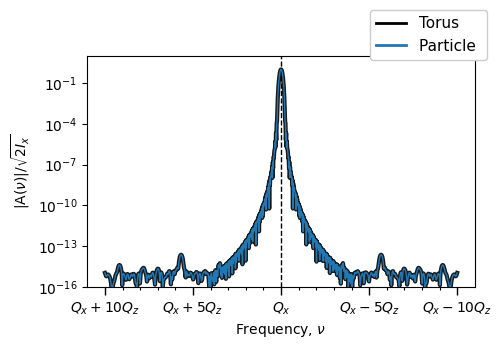

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import nafflib
import pytori as pt
import pytori.plotting as ptplt
import xtrack as xt
import xobjects as xo
import BBStudies.Tracking.Buffers as xBuff

#- PARAMETERS ---------------------------------------------------
beta_rel = 0.99999
# beta_rel = 0.4
n_part  = int(1e4)
# Irrationnal frequencies
#-------------------------------
fx  = 1/2/np.sqrt(2)
fy  = 1/2/np.sqrt(3)
fz  = -1/2/np.sqrt(5)/100
#-------------------------------
Qvec    = [fx,fy,fz]
T_N     = { 'Tx' : 2*np.pi*Qvec[0]*np.arange(n_part),
            'Ty' : 2*np.pi*Qvec[1]*np.arange(n_part),
            'Tz' : 2*np.pi*Qvec[2]*np.arange(n_part)}
#----------------------------------------------------------------------
rx_vec = np.array([np.sqrt(2*1e-2)])
ry_vec = np.array([np.sqrt(2*1e-2)])
rz_vec = np.array([np.sqrt(2*1e-2)])

# rx_vec = np.array([2    ,3]) * 1e-1
# ry_vec = np.array([2    ,3]) * 1e-1
# rz_vec = np.array([2    ,1e-16]) * 1e-1

tori    = []
for rx,ry,rz in zip(rx_vec.flatten(),ry_vec.flatten(),rz_vec.flatten()):
    tori.append(pt.Torus(   x={(1,0,0)  : rx},
                            y={(0,1,0)  : ry},
                            z={(0,0,1)  : rz}))
n_torus = len(tori)
#----------------------------------------------------------------------



# BEAM
#=========================================================================================
nrj             = 7000e9
nemitt_x        = 2.5e-6
nemitt_y        = 2.5e-6
nemitt_z        = 0.06207557250851159
#-----------------------------------------------------------------------------------------
particle_ref    = xt.Particles(p0c=nrj, q0=1, mass0=xt.PROTON_MASS_EV)
context         = xo.ContextCpu(omp_num_threads='auto')
gemitt_x        = 1 if nemitt_x is None else ( nemitt_x / particle_ref.beta0[0] / particle_ref.gamma0[0])
gemitt_y        = 1 if nemitt_y is None else ( nemitt_y / particle_ref.beta0[0] / particle_ref.gamma0[0])
gemitt_z        = 1 if nemitt_z is None else ( nemitt_z / particle_ref.beta0[0] / particle_ref.gamma0[0])
gemitt          = np.array([gemitt_x,gemitt_y,gemitt_z])
#===



#========================================
# LINE

m0_name = 'monitor_entry'
m1_name = 'monitor_exit'
m_names = [m0_name,m1_name]
m0 = xt.ParticlesMonitor(  _context     = context,
                        num_particles   = int(n_torus*n_part) ,
                        start_at_turn   = 0, 
                        stop_at_turn    = 1)
m1 = m0.copy()
#---------------------------------------
L    = 1
line = xt.Line(
    elements={
        'start_cell': xt.Marker(),
        m0_name: m0,
        'drift1'    : xt.Drift(length=L),
        m1_name: m1,
        'end_cell'  : xt.Marker(),
    }
)
line.config.XTRACK_GLOBAL_XY_LIMIT = 100
line.particle_ref = xt.Particles(beta0=beta_rel,q0=1, mass0=xt.PROTON_MASS_EV)
line.build_tracker(_context=context)
#---------------------------------------


# Tracking
# GENERATING PARTICLES
#=======================================================================
init_coord = {'x':[],'px':[],'y':[],'py':[],'zeta':[],'pzeta':[]}
for torus in tori:
    init_coord[f'x']        += list(torus.X(**T_N))
    init_coord[f'px']       += list(torus.PX(**T_N))
    init_coord[f'y']        += list(torus.Y(**T_N))
    init_coord[f'py']       += list(torus.PY(**T_N))
    init_coord[f'zeta']     += list(torus.Z(**T_N))
    init_coord[f'pzeta']    += list(torus.PZ(**T_N))
#=======================================================================


# TRACKING
#=======================================================================
particles = line.build_particles(   **init_coord,_context= context)
line.track(particles, num_turns= 1,turn_by_turn_monitor=True,with_progress=True)
# clear_output()
#==================================

m_list  = [m1]
b_list  = []
df_list = []
x_tori  = []
for m_name,m in zip(m_names,m_list):
    # Buffer
    #=======================================================================
    buffer  = xBuff.TORUS_Buffer(complex2tuple=False,normalize=False)
    #---------------------------------------------------------
    buffer.n_torus         = n_torus
    buffer.n_points        = n_part
    buffer.n_harm          = 50
    buffer.window_order    = 4
    buffer.window_type     = 'hann'
    buffer.multiprocesses  = 8
    #=======================================================================

    buffer.process(monitor=m)
    df = buffer.to_pandas().groupby('turn').get_group(0).set_index('torus')
    b_list.append(buffer)
    df_list.append(df)

    # Analysis
    for t_index,_torus in df.iterrows():
        
        try:
            # nvec ---------------------------------
            max_n       = buffer.n_harm//2
            max_alias   = 3
            warning_tol = np.inf
            nx  = nafflib.linear_combinations(_torus.Qx,Qvec = Qvec,max_n=max_n,max_alias=max_alias,warning_tol=warning_tol)
            ny  = nafflib.linear_combinations(_torus.Qy,Qvec = Qvec,max_n=max_n,max_alias=max_alias,warning_tol=warning_tol)
            nz  = nafflib.linear_combinations(_torus.Qzeta,Qvec = Qvec,max_n=max_n,max_alias=max_alias,warning_tol=warning_tol)
            #---------------------------------------

        except:
            nx = [(np.nan,np.nan,np.nan,np.nan)]
            ny = [(np.nan,np.nan,np.nan,np.nan)]
            nz = [(np.nan,np.nan,np.nan,np.nan)]

        x_tori.append(pt.Torus.from_naff(n=[nx,ny,nz], A=[_torus.Ax,_torus.Ay,_torus.Azeta]))

        


# Lie transform
t_tori = []
t_tori_full = []
for torus in tori:

    # Psi = pt.Torus()
    Psi = torus.copy()
    Psi = pt.transforms.drift(Psi,ds=L,beta_rel=beta_rel,order=5)
    t_tori.append(Psi)

    Psi = torus.copy()
    Psi = pt.transforms.drift(Psi,ds=L,beta_rel=beta_rel,order=20)
    # Psi.x,Psi.y,Psi.z = pt.transforms.drift(Psi.x,Psi.y,Psi.z,ds=-L,beta_rel=beta_rel,order=20)
    t_tori_full.append(Psi)




    

#=========================================================================================




# PLOTTING
#-----------------------------------------------------------------------------------------
# thesis.clear_output()

T_vec   = np.linspace(0,2*np.pi,200)
Sh_vec  = np.linspace(0,2*np.pi,100)

fig, axes = plt.subplots(1, 3, figsize=(12.2,4))

for m,color in zip([m0,m1],['k','C3']):
    for plane,ax in zip(['x','y','zeta'],axes):
        plt.sca(ax)
        x,px = getattr(m,f'{plane}'),getattr(m,f'p{plane}')
        plt.plot(x,px,'.',color=color,alpha=0.3,ms=1)

# for torus in tori:
#     for plane,ax in zip(['x','y','z'],axes):
#         plt.sca(ax)

#         x,px = torus.get




# for idx,ax in enumerate(axes):
for plane,ax in zip(['x','y','zeta'],axes):
    plt.sca(ax)
    plt.sca(ax)

    # xlim = 1.1*np.max(getattr(m,f'{plane}'))
    # ylim = 1.1*np.max(getattr(m,f'p{plane}'))

    lims = 2*np.max({'x':rx_vec,'y':ry_vec,'zeta':rz_vec}[plane])
    xlim = lims
    ylim = lims

    plt.xlim(-xlim,xlim)
    plt.ylim(-ylim,ylim)
    ax.set_box_aspect(1)



# plt.figure(12,5)
ii  = 0
nu  = np.linspace(Qvec[0]-np.abs(10*Qvec[2]),Qvec[0]+np.abs(10*Qvec[2]),1000) 

t_z       = t_tori[ii].eval('x',**T_N)
t_dffts   = nafflib.naff_dfft(nu, t_z, num_harmonics=1, window_order=4, window_type="hann")

tfull_z       = t_tori_full[ii].eval('x',**T_N)
tfull_dffts   = nafflib.naff_dfft(nu, tfull_z , num_harmonics=1, window_order=4, window_type="hann")

_z       = m1.x[int(n_part*ii):int(n_part*(ii+1)),0] - 1j*m1.px[int(n_part*ii):int(n_part*(ii+1)),0]
_dffts   = nafflib.naff_dfft(nu, _z, num_harmonics=1, window_order=4, window_type="hann")


c1 = 'k'
c2 = 'C0'
c3 = 'indianred'


plt.figure(figsize=(5,3))



plt.plot(nu, np.abs(t_dffts[0])/rx_vec[ii]      ,'-'    ,color=c3 ,lw=5 ,alpha=0.8)
plt.plot(nu, np.abs(tfull_dffts[0])/rx_vec[ii]  ,'-'    ,color=c1 ,lw=3 ,alpha=0.9)
plt.plot(nu, np.abs(_dffts[0])/rx_vec[ii]       ,'-'    ,color=c2 ,lw=1 ,alpha=1.0)


ax = plt.gca()
l1, = ax.plot(np.nan,np.nan,color=c1,lw=2,label=r'Torus ')
l2, = ax.plot(np.nan,np.nan,color=c2,lw=2,label='Particle ')
l3, = ax.plot(np.nan,np.nan,color=c3,lw=2,label=r'Torus ')

# # First legend for solid lines
# legend1 = ax.legend(handles=[l3,l1, l2],fontsize=9,bbox_to_anchor=(1, 1))
# # legend2 = ax.legend(handles=[l3]    ,fontsize=9, loc="upper left")
# ax.add_artist(legend1)  
# # ax.add_artist(legend2)

plt.legend(handles=[l3,l1, l2],fontsize=11,framealpha=1,bbox_to_anchor=(1.05, 0.95),loc='lower right')


plt.yscale('log')
plt.xlabel(r'Frequency, $\nu$')
plt.ylabel(r'$|\mathrm{A}(\nu)|/\sqrt{2I_x}$')

plt.axvline(fx,color='k',ls='--',lw=1,zorder=-20)

from matplotlib.ticker import MultipleLocator, FixedLocator, LogLocator

Qx,Qz = Qvec[0],Qvec[2]
# Major ticks at Qx and ±5 Qz
major_positions = [Qx - 10*Qz,Qx - 5*Qz, Qx, Qx + 5*Qz,Qx  + 10*Qz]
major_labels = [r"$Q_x - 10Q_z$",r"$Q_x - 5Q_z$", r"$Q_x$", r"$Q_x + 5Q_z$",r"$Q_x + 10Q_z$"]


ax.xaxis.set_major_locator(FixedLocator(major_positions))
ax.xaxis.set_major_formatter(lambda val, pos: {
    Qx - 10*Qz: r"$Q_x - 10Q_z$",
    Qx - 5*Qz: r"$Q_x - 5Q_z$",
    Qx: r"$Q_x$",
    Qx + 5*Qz: r"$Q_x + 5Q_z$",
    Qx + 10*Qz: r"$Q_x + 10Q_z$",
}.get(val, ""))

# Minor ticks for *every* sideband (multiples of Qz around Qx)
minor_positions = [Qx + i*Qz for i in range(-10, 11)]
ax.xaxis.set_minor_locator(FixedLocator(minor_positions))
ax.tick_params(axis="x", which="major", length=6, width=1   , labelsize=10)
ax.tick_params(axis="x", which="minor", length=2, width=0.8 , labelsize=10)
# Center the labels horizontally
for label in ax.get_xticklabels():
    label.set_horizontalalignment('center')

plt.ylim(1e-16,1e1)





tfull_z       = tori[ii].eval('x',**T_N)
tfull_dffts   = nafflib.naff_dfft(nu, tfull_z , num_harmonics=1, window_order=4, window_type="hann")

_z       = m0.x[int(n_part*ii):int(n_part*(ii+1)),0] - 1j*m0.px[int(n_part*ii):int(n_part*(ii+1)),0]
_dffts   = nafflib.naff_dfft(nu, _z, num_harmonics=1, window_order=4, window_type="hann")


c1 = 'k'
c2 = 'C0'
c3 = 'indianred'


plt.figure(figsize=(5,3))



# plt.plot(nu, np.abs(t_dffts[0])/rx_vec[ii]      ,'-'    ,color=c3 ,lw=5 ,alpha=0.8)
plt.plot(nu, np.abs(tfull_dffts[0])/rx_vec[ii]  ,'-'    ,color=c1 ,lw=3 ,alpha=0.9)
plt.plot(nu, np.abs(_dffts[0])/rx_vec[ii]       ,'-'    ,color=c2 ,lw=1 ,alpha=1.0)


ax = plt.gca()
l1, = ax.plot(np.nan,np.nan,color=c1,lw=2,label=r'Torus')
l2, = ax.plot(np.nan,np.nan,color=c2,lw=2,label='Particle ')

# # First legend for solid lines
# legend1 = ax.legend(handles=[l3,l1, l2],fontsize=9,bbox_to_anchor=(1, 1))
# # legend2 = ax.legend(handles=[l3]    ,fontsize=9, loc="upper left")
# ax.add_artist(legend1)  
# # ax.add_artist(legend2)

plt.legend(handles=[l1, l2],fontsize=11,framealpha=1,bbox_to_anchor=(1.05, 0.95),loc='lower right')


plt.yscale('log')
plt.xlabel(r'Frequency, $\nu$')
plt.ylabel(r'$|\mathrm{A}(\nu)|/\sqrt{2I_x}$')

plt.axvline(fx,color='k',ls='--',lw=1,zorder=-20)

from matplotlib.ticker import MultipleLocator, FixedLocator, LogLocator

Qx,Qz = Qvec[0],Qvec[2]
# Major ticks at Qx and ±5 Qz
major_positions = [Qx - 10*Qz,Qx - 5*Qz, Qx, Qx + 5*Qz,Qx  + 10*Qz]
major_labels = [r"$Q_x - 10Q_z$",r"$Q_x - 5Q_z$", r"$Q_x$", r"$Q_x + 5Q_z$",r"$Q_x + 10Q_z$"]


ax.xaxis.set_major_locator(FixedLocator(major_positions))
ax.xaxis.set_major_formatter(lambda val, pos: {
    Qx - 10*Qz: r"$Q_x - 10Q_z$",
    Qx - 5*Qz: r"$Q_x - 5Q_z$",
    Qx: r"$Q_x$",
    Qx + 5*Qz: r"$Q_x + 5Q_z$",
    Qx + 10*Qz: r"$Q_x + 10Q_z$",
}.get(val, ""))

# Minor ticks for *every* sideband (multiples of Qz around Qx)
minor_positions = [Qx + i*Qz for i in range(-10, 11)]
ax.xaxis.set_minor_locator(FixedLocator(minor_positions))
ax.tick_params(axis="x", which="major", length=6, width=1   , labelsize=10)
ax.tick_params(axis="x", which="minor", length=2, width=0.8 , labelsize=10)
# Center the labels horizontally
for label in ax.get_xticklabels():
    label.set_horizontalalignment('center')

plt.ylim(1e-16,1e1)




In [5]:
import numpy as np
import matplotlib.pyplot as plt

import nafflib
import pytori as pt
import pytori.plotting as ptplt
import xtrack as xt
import xobjects as xo
import BBStudies.Tracking.Buffers as xBuff

#- PARAMETERS ---------------------------------------------------
beta_rel = 0.99999
# beta_rel = 0.4
n_part  = int(1e4)
# Irrationnal frequencies
#-------------------------------
fx  = 1/2/np.sqrt(2)
fy  = 1/2/np.sqrt(3)
fz  = -1/2/np.sqrt(5)/100
#-------------------------------
Qvec    = [fx,fy,fz]
T_N     = { 'Tx' : 2*np.pi*Qvec[0]*np.arange(n_part),
            'Ty' : 2*np.pi*Qvec[1]*np.arange(n_part),
            'Tz' : 2*np.pi*Qvec[2]*np.arange(n_part)}
#----------------------------------------------------------------------
rx_vec = np.array([np.sqrt(2*1e-2)])
ry_vec = np.array([np.sqrt(2*1e-2)])
rz_vec = np.array([np.sqrt(2*1e-2)])

# rx_vec = np.array([2    ,3]) * 1e-1
# ry_vec = np.array([2    ,3]) * 1e-1
# rz_vec = np.array([2    ,1e-16]) * 1e-1

tori    = []
for rx,ry,rz in zip(rx_vec.flatten(),ry_vec.flatten(),rz_vec.flatten()):
    tori.append(pt.Torus(   x={(1,0,0)  : rx},
                            y={(0,1,0)  : ry},
                            z={(0,0,1)  : rz}))
n_torus = len(tori)
#----------------------------------------------------------------------






# Tracking
# GENERATING PARTICLES
#=======================================================================
init_coord = {'x':[],'px':[],'y':[],'py':[],'zeta':[],'pzeta':[]}
for torus in tori:
    init_coord[f'x']        += list(torus.X(**T_N))
    init_coord[f'px']       += list(torus.PX(**T_N))
    init_coord[f'y']        += list(torus.Y(**T_N))
    init_coord[f'py']       += list(torus.PY(**T_N))
    init_coord[f'zeta']     += list(torus.Z(**T_N))
    init_coord[f'pzeta']    += list(torus.PZ(**T_N))
#=======================================================================


# TRACKING
#=======================================================================
L=1.0
drift = xt.Drift(length=L)

particles = xt.Particles(**init_coord,beta0=beta_rel,q0=1, mass0=xt.PROTON_MASS_EV)
drift.track(particles)






# Lie transform
t_tori = []
t_tori_full = []
for torus in tori:

    # Psi = pt.Torus()
    Psi = torus.copy()
    Psi = pt.transforms.drift(Psi,ds=L,beta_rel=beta_rel,order=5)
    t_tori.append(Psi)

    Psi = torus.copy()
    Psi = pt.transforms.drift(Psi,ds=L,beta_rel=beta_rel,order=20)
    # Psi.x,Psi.y,Psi.z = pt.transforms.drift(Psi.x,Psi.y,Psi.z,ds=-L,beta_rel=beta_rel,order=20)
    t_tori_full.append(Psi)


Psi_0 = tori[0].copy()
Psi_1 = t_tori_full[0].copy()



print('x',np.max(np.abs(Psi_1.X(**T_N) - particles.x)))
print('y',np.max(np.abs(Psi_1.Y(**T_N) - particles.y)))
print('zeta',np.max(np.abs(Psi_1.Z(**T_N) - particles.zeta)))
    

beta_rel: 0.99999
beta_rel: 0.99999
x 3.583244811977693e-14
y 3.6110003875933216e-14
zeta 5.768024946561923e-13


np.float64(3.583244811977693e-14)

In [9]:
particles.x

array([ 0.14142136, -0.19796378,  0.09812273, ..., -0.16070034,
        0.17837321, -0.05548646])

In [8]:
drift.track(particles)

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


In [40]:
rz_vec

array([0.14142136])

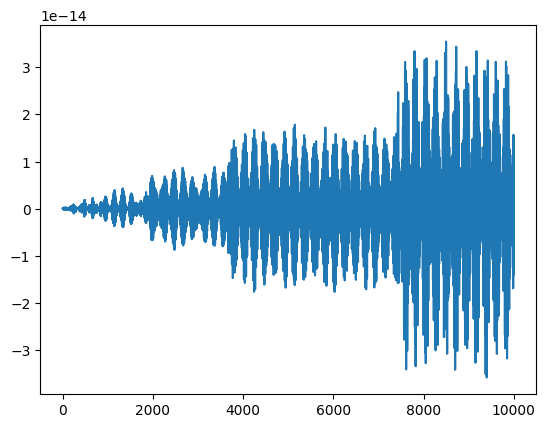

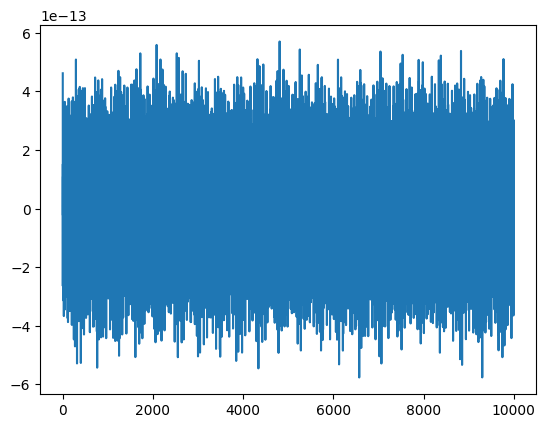

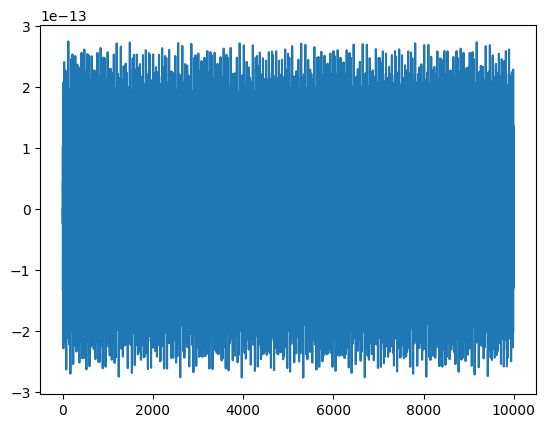

In [4]:
plt.figure()
plt.plot(t_tori_full[0].X(**T_N)[:]- m1.x[:,0])

plt.figure()
plt.plot(t_tori_full[0].Z(**T_N)[:]- m1.zeta[:,0])

plt.figure()
plt.plot(t_tori_full[0].PZ(**T_N)[:]- m1.pzeta[:,0])
# plt.plot(m1.x[:100,0])

In [1]:
# ============================================================
# pytest: pytori transforms vs ducktrack reference elements
# ============================================================
import numpy as np
import pytest

import ducktrack as dtk
import pytori.mathlib as mathlib
from pytori.series import FourierSeries
from pytori.tori import Torus
import pytori.transforms as transforms  # your drift, bend, multipole, etc.
import matplotlib.pyplot as plt

import numpy as np
import pytest
import pathlib
from cpymad.madx import Madx
from scipy.stats import linregress
from scipy import constants as cst
import ducktrack as dtk
import xobjects as xo
import xpart as xp
import xtrack as xt
# from xobjects.test_helpers import for_all_test_contexts, fix_random_seed
# from xtrack.beam_elements.elements import _angle_from_trig



# ============================================================
# Global reference particle ("on closed orbit")
# ============================================================

# Global energy template for all particles (7 TeV proton, nominal LHC scale)
particle_on_co = dtk.TestParticles(
    p0c=7e12,  # 7 TeV
    x=0, px=0,
    y=0, py=0,
    zeta=0, pzeta=0,
)

# ============================================================
# Helpers
# ============================================================

def make_simple_torus(dim=3, amp=1e-3):
    """
    Build a minimal test Torus with one Fourier mode per plane:
        x(Θ) = A_x e^{iΘ_x}
        y(Θ) = A_y e^{iΘ_y}
        z(Θ) = A_z e^{iΘ_z}
    """
    coeff_x = {(1, 0, 0): amp * np.exp(1j * 0.1)}
    coeff_y = {(0, 1, 0): amp * np.exp(1j * 0.2)}
    coeff_z = {(0, 0, 1): amp * np.exp(1j * 0.3)}

    return Torus(
        x=FourierSeries(coeff_x, dim=dim, mp="numpy"),
        y=FourierSeries(coeff_y, dim=dim, mp="numpy"),
        z=FourierSeries(coeff_z, dim=dim, mp="numpy"),
        bet0=(1.0, 1.0, 1.0),
    )


def torus_to_particles(Psi, Tx, Ty, Tz):
    """
    Evaluate Torus over arrays of (Tx, Ty, Tz) and return ducktrack.TestParticles.
    Uses the global particle_on_co as a template.
    """
    x = Psi.X(Tx, Ty, Tz)
    px = Psi.PX(Tx, Ty, Tz)
    y = Psi.Y(Tx, Ty, Tz)
    py = Psi.PY(Tx, Ty, Tz)
    zeta = Psi.Z(Tx, Ty, Tz)
    pzeta = Psi.PZ(Tx, Ty, Tz)

    return dtk.TestParticles(
        p0c = particle_on_co.p0c,
        x=x.ravel(), px=px.ravel(),
        y=y.ravel(), py=py.ravel(),
        zeta=zeta.ravel(), pzeta=pzeta.ravel(),
    )


def compare_torus_vs_ducktrack(Psi_new, dtk_final, Tx, Ty, Tz, rtol=1e-6, atol=1e-10):
    """
    Compare pytori transform results to ducktrack reference at given arrays of phases.
    """
    x_t = Psi_new.X(Tx, Ty, Tz).ravel()
    px_t = Psi_new.PX(Tx, Ty, Tz).ravel()
    y_t = Psi_new.Y(Tx, Ty, Tz).ravel()
    py_t = Psi_new.PY(Tx, Ty, Tz).ravel()
    z_t = Psi_new.Z(Tx, Ty, Tz).ravel()
    pz_t = Psi_new.PZ(Tx, Ty, Tz).ravel()

    np.testing.assert_allclose(x_t, dtk_final.x, rtol=rtol, atol=atol, err_msg="Mismatch in x")
    np.testing.assert_allclose(px_t, dtk_final.px, rtol=rtol, atol=atol, err_msg="Mismatch in px")
    np.testing.assert_allclose(y_t, dtk_final.y, rtol=rtol, atol=atol, err_msg="Mismatch in y")
    np.testing.assert_allclose(py_t, dtk_final.py, rtol=rtol, atol=atol, err_msg="Mismatch in py")
    np.testing.assert_allclose(z_t, dtk_final.zeta, rtol=rtol, atol=atol, err_msg="Mismatch in zeta")
    np.testing.assert_allclose(pz_t, dtk_final.pzeta, rtol=rtol, atol=atol, err_msg="Mismatch in pzeta")


# ============================================================
# Common 3D phase grid
# ============================================================

@pytest.fixture(scope="module")
def phase_grid():
    """3D phase mesh for evaluating the torus."""
    Tx = np.linspace(0, 2 * np.pi, 5)
    Ty = np.linspace(0, 2 * np.pi, 5)
    Tz = np.linspace(0, 2 * np.pi, 5)
    return np.meshgrid(Tx, Ty, Tz, indexing="ij")


# ============================================================
# Tests
# ============================================================

"""Compare pytori.drift with ducktrack.DriftExact."""
Tx = np.linspace(0, 2 * np.pi, 5)
Ty = np.linspace(0, 2 * np.pi, 5)
Tz = np.linspace(0, 2 * np.pi, 5)
# Tx, Ty, Tz = np.meshgrid(Tx, Ty, Tz, indexing="ij")
Psi = make_simple_torus()

ds = 1.0

# --- Reference: ducktrack
dtk_particles = torus_to_particles(Psi, Tx, Ty, Tz)
el_dtk = dtk.elements.Drift(length=ds)  # exact symplectic drift
el_dtk.track(dtk_particles)

# --- pytori: drift map
Psi_new = transforms.drift(Psi, ds=ds, particle_on_co=particle_on_co)
compare_torus_vs_ducktrack(Psi_new, dtk_particles, Tx, Ty, Tz)

beta_rel: 0.9999999910167908


In [2]:
dtk_particles

        mass0   = 938272088.1604904
        p0c     = 1000000000.0
        energy0 = 1371260190.9998872
        beta0   = 0.7292562028442071
        gamma0  = 1.461473924571584
        s       = 1.0
        x       = [ 0.00089514 -0.00109579 -0.0008952   0.00109389  0.00089514]
        px      = [-9.98334166e-05 -9.95004165e-04  9.98334166e-05  9.95004165e-04
 -9.98334166e-05]
        y       = [ 0.00078134 -0.00117967 -0.00078146  0.0011778   0.00078134]
        py      = [-0.00019867 -0.00098007  0.00019867  0.00098007 -0.00019867]
        zeta    = [ 0.00081689 -0.00074441 -0.00081706  0.00074118  0.00081689]
        delta   = [-0.00029554 -0.00095555  0.0002955   0.00095512 -0.00029554]
        ptau    = [-0.00021551 -0.00069669  0.00021551  0.00069669 -0.00021551]
        mass_ratio  = 1.0
        charge_ratio  = 1.0
        chi     = 1.0
        state   = [1. 1. 1. 1. 1.]
        weight  = [1. 1. 1. 1. 1.]

In [20]:
Tx

array([0.        , 1.57079633, 3.14159265, 4.71238898, 6.28318531])

In [21]:
Psi.Y(Tx, Ty, Tz).shape

(5,)

In [7]:
context         = xo.ContextCpu(omp_num_threads='auto')
test_context = context
dtk_particle = dtk.TestParticles(
        p0c=25.92e9,
        x=1e-3,
        px=1e-5,
        y=-2e-3,
        py=-1.5e-5,
        delta=1e-2,
        zeta=1.)

particles = xp.Particles.from_dict(dtk_particle.to_dict(),
                                    _context=test_context)

drift = xt.Drift(_context=test_context, length=10.)
drift.track(particles)

dtk_drift = dtk.elements.Drift(length=10.)
dtk_drift.track(dtk_particle)

xo.assert_allclose(test_context.nparray_from_context_array(particles.x)[0],
                    dtk_particle.x, rtol=1e-14, atol=1e-14)
xo.assert_allclose(test_context.nparray_from_context_array(particles.y)[0],
                    dtk_particle.y, rtol=1e-14, atol=1e-14)
xo.assert_allclose(test_context.nparray_from_context_array(particles.zeta)[0],
                    dtk_particle.zeta,
                    rtol=1e-14, atol=1e-14)

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


In [17]:
print(Psi_new.Z(Tx,Ty,Tz))
print(dtk_particles.zeta)

[ 0.00095531 -0.0002965  -0.00095536  0.00029455  0.00095531]
[ 0.00081689 -0.00074441 -0.00081706  0.00074118  0.00081689]


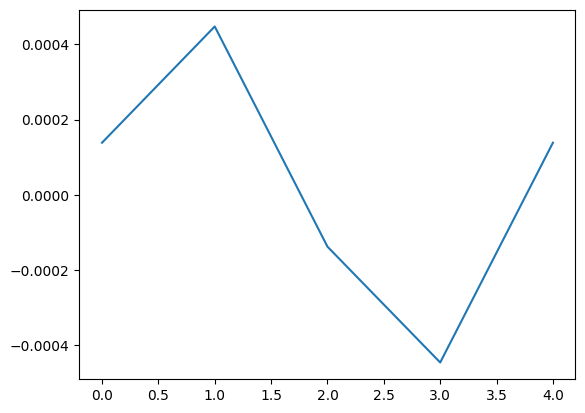

In [12]:
plt.plot(Psi_new.Z(Tx,Ty,Tz)- dtk_particles.zeta)

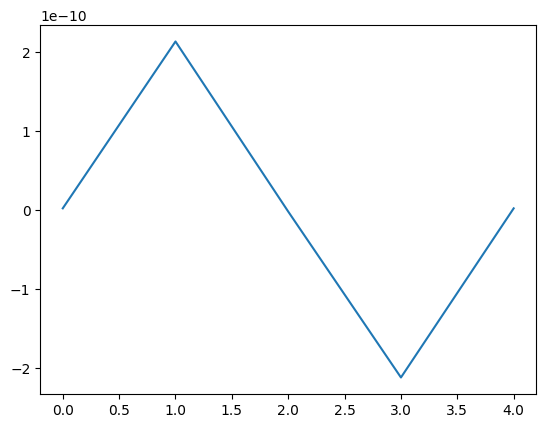

In [11]:
plt.figure()
plt.plot(Psi_new.X(Tx,Ty,Tz)- dtk_particles.x)

In [41]:
Psi

╭─────────────────────────────────────────────── Torus (FourierSeries) ────────────────────────────────────────────────╮
│                                                                                                                      │
│  ╭─────────────────────────── x ────────────────────────────╮                                                        │
│  │                                                          │                                                        │
│  │   Index        Value                       Norm          │                                                        │
│  │   ( 1, 0, 0)   9.95004e-04 + 9.98334e-05j  1.00000e-03   │                                                        │
│  │                                                          │                                                        │
│  ╰──────────────────────── terms=1 ─────────────────────────╯                                                        │
│  ╭─────────────────────────── y ────────────────────────────╮                                                        │
│  │                                                          │                                                        │
│  │   Index        Value                       Norm          │                                                        │
│  │   ( 0, 1, 0)   9.80067e-04 + 1.98669e-04j  1.00000e-03   │                                                        │
│  │                                                          │                                                        │
│  ╰──────────────────────── terms=1 ─────────────────────────╯                                                        │
│  ╭─────────────────────────── z ────────────────────────────╮                                                        │
│  │                                                          │                                                        │
│  │   Index        Value                       Norm          │                                                        │
│  │   ( 0, 0, 1)   9.55336e-04 + 2.95520e-04j  1.00000e-03   │                                                        │
│  │                                                          │                                                        │
│  ╰──────────────────────── terms=1 ─────────────────────────╯                                                        │
│                                                                                                                      │
╰─ dim=3, β₀=(1, 1, 1), (Ix,Iy,Iz)=(5e-07, 5e-07, 5e-07), max_order=None, max_terms=100, numerical_tol=None, backend='─╯

In [ ]:
dtk.elements.

<module 'ducktrack' from '/Users/pbelanger/ABPLocal/BBStudies/Executables/py-BB/xtrack/ducktrack/__init__.py'>